# Credit Card Fraud Detection Pipeline

Deteccion de fraude en transacciones de tarjetas de credito mediante un pipeline completo de Machine Learning:
preparacion de datos, escalado, balanceo de clases, busqueda de hiperparametros, validacion cruzada,
optimizacion de umbral de corte y comparacion de modelos.

**Dataset:** [Credit Card Fraud Detection - Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

## 1. Imports y configuracion

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, f1_score,
    make_scorer, roc_curve, precision_score, recall_score, accuracy_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})

## 2. Carga de datos

In [3]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df_full = pd.read_csv(f"{path}/creditcard.csv")

df_fraude = df_full[df_full["Class"] == 1].sample(n=492, random_state=RANDOM_STATE)
df_legit = df_full[df_full["Class"] == 0].sample(n=7000, random_state=RANDOM_STATE)
df = pd.concat([df_legit, df_fraude]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Distribucion de clases:\n{df['Class'].value_counts()}")
print(f"Ratio fraude: {df['Class'].mean():.4f}")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Shape: (7492, 31)
Distribucion de clases:
Class
0    7000
1     492
Name: count, dtype: int64
Ratio fraude: 0.0657


## 3. Analisis exploratorio rapido

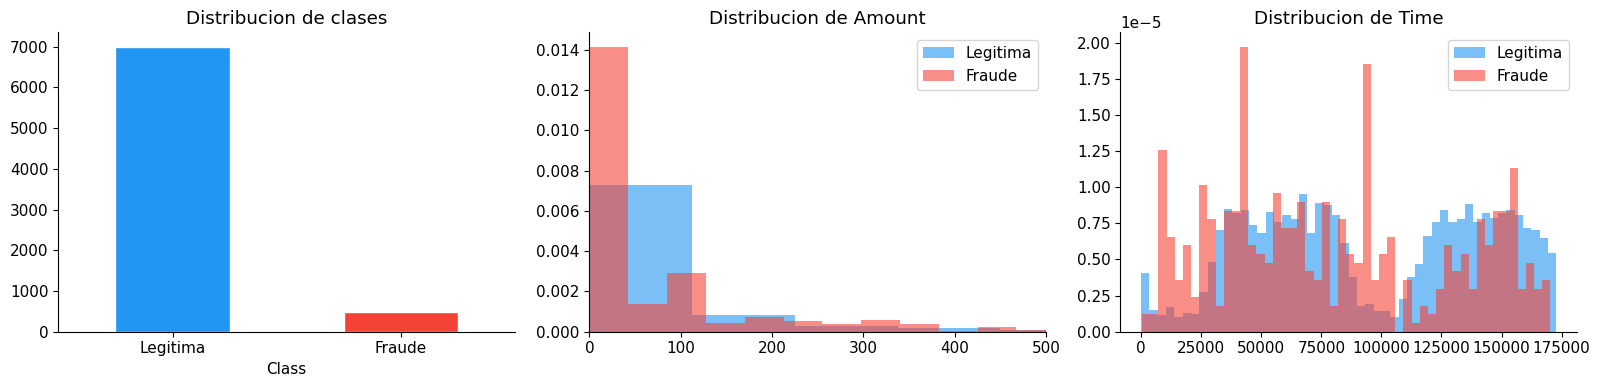

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribucion de clases
df["Class"].value_counts().plot.bar(ax=axes[0], color=["#2196F3", "#F44336"], edgecolor="white")
axes[0].set_title("Distribucion de clases")
axes[0].set_xticklabels(["Legitima", "Fraude"], rotation=0)

# Distribucion de Amount
for cls, color, label in [(0, "#2196F3", "Legitima"), (1, "#F44336", "Fraude")]:
    subset = df[df["Class"] == cls]["Amount"]
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[1].set_title("Distribucion de Amount")
axes[1].set_xlim(0, 500)
axes[1].legend()

# Distribucion de Time
for cls, color, label in [(0, "#2196F3", "Legitima"), (1, "#F44336", "Fraude")]:
    subset = df[df["Class"] == cls]["Time"]
    axes[2].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[2].set_title("Distribucion de Time")
axes[2].legend()

plt.tight_layout()
plt.show()

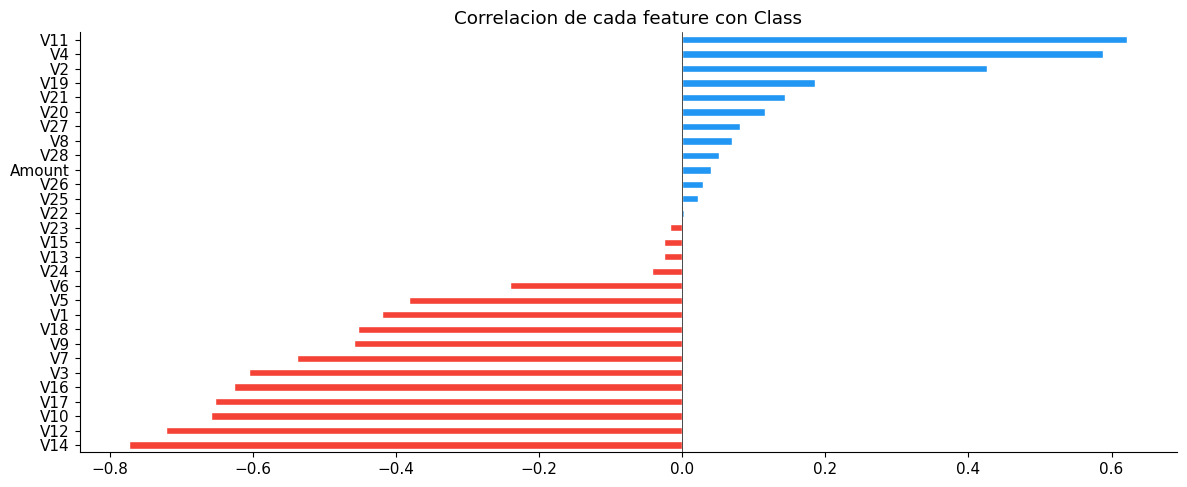

In [5]:
# Correlacion de las variables V con la clase objetivo
correlations = df.drop(columns=["Time"]).corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#F44336" if v < 0 else "#2196F3" for v in correlations.values]
correlations.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_title("Correlacion de cada feature con Class")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 4. Preparacion de datos

In [6]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train fraude ratio: {y_train.mean():.4f}")
print(f"Test  fraude ratio: {y_test.mean():.4f}")

Train: (5993, 30), Test: (1499, 30)
Train fraude ratio: 0.0657
Test  fraude ratio: 0.0654


## 5. Definicion de modelos, escaladores y tecnicas de balanceo

Se definen las combinaciones de:
- **Escaladores:** StandardScaler, RobustScaler
- **Balanceo:** Sin balanceo, SMOTE, ADASYN, RandomUnderSampler, SMOTETomek
- **Modelos:** LogisticRegression, RandomForest, GradientBoosting, XGBoost, SVC

In [7]:
scalers = {
    "Standard": StandardScaler(),
    "Robust": RobustScaler(),
}

balancers = {
    "None": None,
    "SMOTE": SMOTE(random_state=RANDOM_STATE),
    "RUS": RandomUnderSampler(random_state=RANDOM_STATE),
}

models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RF": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "GBM": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGB": XGBClassifier(
        random_state=RANDOM_STATE, eval_metric="logloss",
        use_label_encoder=False, n_jobs=-1, verbosity=0
    ),
}

param_grids = {
    "LogReg": {"model__C": [0.1, 1], "model__penalty": ["l2"]},
    "RF": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10],
    },
    "GBM": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
    },
    "XGB": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
    },
}

## 6. Busqueda de hiperparametros con validacion cruzada

Para cada combinacion (escalador, balanceo, modelo) se ejecuta `GridSearchCV`
con `StratifiedKFold(5)` optimizando `average_precision` (mas adecuada que accuracy en datos desbalanceados).

> **Nota:** esta celda puede tardar varios minutos.

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = "average_precision"

results = []

for scaler_name, scaler in scalers.items():
    for bal_name, balancer in balancers.items():
        for model_name, model in models.items():

            steps = [("scaler", scaler)]
            if balancer is not None:
                steps.append(("balancer", balancer))
            steps.append(("model", model))

            if balancer is not None:
                pipe = ImbPipeline(steps)
            else:
                pipe = Pipeline([("scaler", scaler), ("model", model)])

            grid = GridSearchCV(
                pipe,
                param_grids[model_name],
                cv=cv,
                scoring=scoring,
                n_jobs=-1,
                refit=True,
                error_score="raise",
            )

            grid.fit(X_train, y_train)

            results.append({
                "scaler": scaler_name,
                "balancer": bal_name,
                "model": model_name,
                "best_params": grid.best_params_,
                "cv_score": grid.best_score_,
                "estimator": grid.best_estimator_,
            })

            print(f"{scaler_name:>10} | {bal_name:>10} | {model_name:>6} | AP={grid.best_score_:.4f}")

results_df = pd.DataFrame(results)

  Standard |       None | LogReg | AP=0.9370
  Standard |       None |     RF | AP=0.9272


## 7. Mejor combinacion por modelo

In [ ]:
best_per_model = (
    results_df
    .sort_values("cv_score", ascending=False)
    .groupby("model")
    .first()
    .reset_index()
    .sort_values("cv_score", ascending=False)
)

display_cols = ["model", "scaler", "balancer", "cv_score", "best_params"]
best_per_model[display_cols].reset_index(drop=True)

## 8. Evaluacion en test y busqueda de umbral optimo

Para cada mejor modelo se busca el umbral de probabilidad que maximiza el F1-score
en el conjunto de test.

In [ ]:
def find_best_threshold(y_true, y_proba, metric="f1"):
    thresholds = np.arange(0.05, 0.96, 0.01)
    scores = []
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        scores.append(f1_score(y_true, preds, zero_division=0))
    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx]


test_results = []

for _, row in best_per_model.iterrows():
    estimator = row["estimator"]
    y_proba = estimator.predict_proba(X_test)[:, 1]
    best_thresh, best_f1 = find_best_threshold(y_test, y_proba)
    y_pred = (y_proba >= best_thresh).astype(int)

    test_results.append({
        "model": row["model"],
        "scaler": row["scaler"],
        "balancer": row["balancer"],
        "threshold": best_thresh,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "avg_precision": average_precision_score(y_test, y_proba),
        "y_proba": y_proba,
        "y_pred": y_pred,
    })

test_df = pd.DataFrame(test_results).sort_values("f1", ascending=False).reset_index(drop=True)
metric_cols = ["model", "scaler", "balancer", "threshold", "accuracy", "precision", "recall", "f1", "roc_auc", "avg_precision"]
test_df[metric_cols]

## 9. Comparacion visual de metricas

In [ ]:
plot_df = test_df[["model", "precision", "recall", "f1", "roc_auc", "avg_precision"]].set_index("model")

fig, ax = plt.subplots(figsize=(14, 5))
plot_df.plot.bar(ax=ax, edgecolor="white", width=0.8)
ax.set_title("Comparacion de metricas por modelo (test)")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc="lower right", framealpha=0.9)
ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

## 10. Curvas ROC y Precision-Recall

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set1(np.linspace(0, 1, len(test_df)))

for i, row in test_df.iterrows():
    fpr, tpr, _ = roc_curve(y_test, row["y_proba"])
    axes[0].plot(fpr, tpr, color=colors[i], label=f"{row['model']} (AUC={row['roc_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.5)
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=9)

for i, row in test_df.iterrows():
    prec, rec, _ = precision_recall_curve(y_test, row["y_proba"])
    axes[1].plot(rec, prec, color=colors[i], label=f"{row['model']} (AP={row['avg_precision']:.3f})")

axes[1].set_title("Curva Precision-Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11. Matrices de confusion

In [ ]:
n_models = len(test_df)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, test_df.iterrows()):
    cm = confusion_matrix(y_test, row["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Legit", "Fraude"], yticklabels=["Legit", "Fraude"],
        cbar=False, linewidths=0.5
    )
    ax.set_title(f"{row['model']}\n(t={row['threshold']:.2f})")
    ax.set_ylabel("Real")
    ax.set_xlabel("Prediccion")

plt.tight_layout()
plt.show()

## 12. Analisis de sensibilidad del umbral (mejor modelo)

In [ ]:
best = test_df.iloc[0]
y_proba_best = best["y_proba"]

thresholds = np.arange(0.05, 0.96, 0.01)
metrics_by_thresh = []

for t in thresholds:
    preds = (y_proba_best >= t).astype(int)
    metrics_by_thresh.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    })

thresh_df = pd.DataFrame(metrics_by_thresh)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", linewidth=2)
ax.plot(thresh_df["threshold"], thresh_df["recall"], label="Recall", linewidth=2)
ax.plot(thresh_df["threshold"], thresh_df["f1"], label="F1", linewidth=2, linestyle="--")
ax.axvline(best["threshold"], color="red", linestyle=":", label=f"Umbral optimo ({best['threshold']:.2f})")
ax.set_title(f"Precision / Recall / F1 vs Umbral - {best['model']}")
ax.set_xlabel("Umbral de probabilidad")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Validacion cruzada final del mejor modelo

In [ ]:
#best_estimator = best["estimator"]
best_estimator = search.best_estimator_

cv_results = cross_validate(
    best_estimator, X_train, y_train,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
    scoring=["average_precision", "roc_auc", "f1"],
    return_train_score=True,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "Metrica": ["Average Precision", "ROC AUC", "F1"],
    "Train (media)": [
        cv_results["train_average_precision"].mean(),
        cv_results["train_roc_auc"].mean(),
        cv_results["train_f1"].mean(),
    ],
    "Train (std)": [
        cv_results["train_average_precision"].std(),
        cv_results["train_roc_auc"].std(),
        cv_results["train_f1"].std(),
    ],
    "Val (media)": [
        cv_results["test_average_precision"].mean(),
        cv_results["test_roc_auc"].mean(),
        cv_results["test_f1"].mean(),
    ],
    "Val (std)": [
        cv_results["test_average_precision"].std(),
        cv_results["test_roc_auc"].std(),
        cv_results["test_f1"].std(),
    ],
})

cv_summary

## 14. Importancia de features (mejor modelo)

In [ ]:
best_estimator_inner = best["estimator"]

# Extraer el modelo final del pipeline
model_step = best_estimator_inner.named_steps.get("model", None)
if model_step is None:
    model_step = best_estimator_inner[-1]

has_importance = hasattr(model_step, "feature_importances_")
has_coef = hasattr(model_step, "coef_")

if has_importance or has_coef:
    if has_importance:
        importances = model_step.feature_importances_
        title = "Feature Importances"
    else:
        importances = np.abs(model_step.coef_[0])
        title = "Feature Importances (|coef|)"

    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
    feat_imp_top = feat_imp.tail(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp_top.plot.barh(ax=ax, color="#2196F3", edgecolor="white")
    ax.set_title(f"{title} - {best['model']} (Top 15)")
    plt.tight_layout()
    plt.show()
else:
    print(f"El modelo {best['model']} no expone importancias directamente.")

## 15. Resumen ejecutivo

In [ ]:
print(f"Mejor modelo: {best['model']}")
print(f"Configuracion: Scaler={best['scaler']}, Balanceo={best['balancer']}")
print(f"Umbral optimo: {best['threshold']:.2f}")
print(f"F1:            {best['f1']:.4f}")
print(f"Precision:     {best['precision']:.4f}")
print(f"Recall:        {best['recall']:.4f}")
print(f"ROC AUC:       {best['roc_auc']:.4f}")
print(f"Avg Precision: {best['avg_precision']:.4f}")

cm = confusion_matrix(y_test, best["y_pred"])
print(f"\nMatriz de confusion:")
print(f"  TP={cm[1,1]}, FP={cm[0,1]}, FN={cm[1,0]}, TN={cm[0,0]}")